# Reduce the parameter interval to the minimum interval that contains all working simulations

In [3]:
import numpy as np

In [4]:
basefolder = f"/data/HCM/5/scenarios/50/"
output_mask = "output_mask_beat_5.txt"

In [5]:
mask = np.loadtxt(f"{basefolder}/output/{output_mask}",dtype=int)

input_parameters = np.loadtxt(f"{basefolder}/data/X.txt",dtype=float)

input_working = input_parameters[mask == 1]

min_values_original = np.min(input_parameters, axis=0)
max_values_original = np.max(input_parameters, axis=0)

intervals_original = np.column_stack((min_values_original, max_values_original))

min_values_working = np.min(input_working, axis=0)
max_values_working = np.max(input_working, axis=0)

intervals_working = np.column_stack((min_values_working, max_values_working))


In [6]:

# Check if points are within the bounds
within_bounds = np.all((input_parameters >= intervals_original[:, 0]) & (input_parameters <= intervals_original[:, 1]), axis=1)

# Calculate the amount and percentage of points within bounds
amount_within_bounds = np.sum(within_bounds)
percentage_within_bounds = (np.sum(mask) / amount_within_bounds) * 100

print(f"Working: {np.sum(mask)}")

print(f"Initial amount of points: {amount_within_bounds}")
print(f"Initial success rate: {percentage_within_bounds:.2f}%")


# Check if points are within the bounds
within_bounds_working = np.all((input_parameters >= intervals_working[:, 0]) & (input_parameters <= intervals_working[:, 1]), axis=1)

# Calculate the amount and percentage of points within bounds
amount_within_bounds_working = np.sum(within_bounds_working)
percentage_within_bounds_working = (np.sum(mask) / amount_within_bounds_working) * 100

print(f"Reduced amount of points: {amount_within_bounds_working}")
print(f"Increased success rate: {percentage_within_bounds_working:.2f}%")



Working: 74
Initial amount of points: 800
Initial success rate: 9.25%
Reduced amount of points: 238
Increased success rate: 31.09%


In [7]:
np.set_printoptions(suppress=True)

for i in range(len(intervals_original)):
	increase_min = 100*(intervals_working[i][0] - intervals_original[i][0])/(intervals_original[i][1]-intervals_original[i][0])
	
	if increase_min > 5:
		print(f"Label {i}")
		print(f"Original interval: {intervals_original[i]}")
		print(f"Reduced interval: {intervals_working[i]}")
		print(f"Change: min increase by {increase_min}%")
	else:
		decrease_max = 100*(intervals_original[i][1] - intervals_working[i][1])/(intervals_original[i][1]-intervals_original[i][0])

		if decrease_max > 5:
			print(f"Label {i}")
			print(f"Original interval: {intervals_original[i]}")
			print(f"Reduced interval: {intervals_working[i]}")
			print(f"Change: max decreased by {decrease_max}%")


Label 2
Original interval: [0.00092163 0.00251189]
Reduced interval: [0.00092163 0.00233995]
Change: max decreased by 10.812088863623943%
Label 3
Original interval: [135.206 199.704]
Reduced interval: [148.983 199.704]
Change: min increase by 21.360352258984793%
Label 4
Original interval: [0.175616 0.52417 ]
Reduced interval: [0.178127 0.492279]
Change: max decreased by 9.14951485279182%
Label 6
Original interval: [1.86623 2.9983 ]
Reduced interval: [1.96347 2.99762]
Change: min increase by 8.589574849611774%
Label 10
Original interval: [0.0111953 0.0314906]
Reduced interval: [0.0142469 0.0306879]
Change: min increase by 15.035993555158088%
Label 14
Original interval: [0.0351425 0.104365 ]
Reduced interval: [0.0398908 0.0966225]
Change: min increase by 6.8594748817219795%
Label 15
Original interval: [0.0810012 0.184816 ]
Reduced interval: [0.0866517 0.184762 ]
Change: min increase by 5.442865564447461%
Label 23
Original interval: [1.12051 3.3262 ]
Reduced interval: [1.15862 3.04851]
Ch

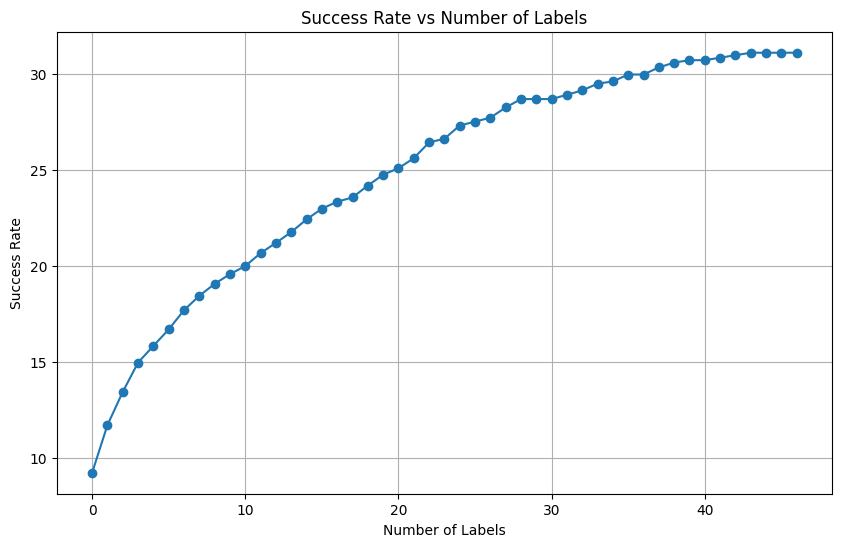

31.092436974789916


In [10]:
import numpy as np
import matplotlib.pyplot as plt


# Filter the rows where mask is 1
input_working = input_parameters[mask == 1]

# Function to calculate success rate
def calculate_success_rate(parameters, intervals):
    within_bounds = np.all((parameters >= intervals[:, 0]) & (parameters <= intervals[:, 1]), axis=1)
    return 100*np.sum(mask) / np.sum(within_bounds)

# Calculate initial success rate
initial_success_rate = calculate_success_rate(input_parameters, intervals_original)

# Calculate success rate increase for each dimension
success_rate_increase = []
dimensions_to_remove = []
final_success_rate = [initial_success_rate]

for i in range(intervals_original.shape[0]):
    reduced_intervals = intervals_original.copy()
    reduced_intervals[i, 0] = np.min(input_working[:, i])
    reduced_intervals[i, 1] = np.max(input_working[:, i])
    success_rate = calculate_success_rate(input_parameters, reduced_intervals)

for i in range(success_rate.shape[0]):

    success_rate_increase.append(success_rate - initial_success_rate)


dimensions_to_remove.append(np.argmax(success_rate_increase))
final_success_rate.append(np.max(success_rate_increase))

# # Sort dimensions based on success rate increase
# sorted_dimensions = np.argsort(success_rate_increase)[::-1]

# # Iteratively reduce intervals and calculate success rate
# success_rates = [initial_success_rate]
# for i in range(1, len(sorted_dimensions) + 1):
#     reduced_intervals = intervals_original.copy()
#     for j in sorted_dimensions[:i]:
#         reduced_intervals[j, 0] = np.min(input_working[:, j])
#         reduced_intervals[j, 1] = np.max(input_working[:, j])
#     success_rate = calculate_success_rate(input_parameters, reduced_intervals)
#     success_rates.append(success_rate)

# # Plot the results
# plt.figure(figsize=(10, 6))
# plt.plot(range(len(success_rates)), success_rates, marker='o')
# plt.xlabel('Number of Labels')
# plt.ylabel('Success Rate')
# plt.title('Success Rate vs Number of Labels')
# plt.grid(True)
# plt.show()


# print(success_rate)

In [15]:
sorted_dimensions

array([40, 23, 30, 10, 37, 22, 42, 45, 26, 14, 36, 18,  3, 44, 38, 35, 28,
       31, 41, 27, 24, 43, 25, 32, 16,  9,  4,  1, 17, 11,  2, 29,  8, 13,
       12,  7, 21, 15,  6,  0, 34, 20,  5, 19, 39, 33])

In [16]:
success_rate_increase

[0.05817610062893053,
 0.12896070975918938,
 0.09343434343434431,
 0.34792477302204894,
 0.15279542566709026,
 0.034818067754077475,
 0.05817610062893053,
 0.08165195460277452,
 0.09343434343434431,
 0.16475826972010132,
 0.5904255319148941,
 0.10524652338811613,
 0.09343434343434431,
 0.09343434343434431,
 0.3728868660598188,
 0.06989924433249328,
 0.20083014048531211,
 0.11708860759493689,
 0.3603896103896105,
 0.034818067754077475,
 0.04648241206030157,
 0.08165195460277452,
 0.5254293262879788,
 1.366929698708752,
 0.21291560102301865,
 0.20083014048531211,
 0.3728868660598188,
 0.21291560102301865,
 0.2738095238095237,
 0.09343434343434431,
 1.013522884882109,
 0.23717948717948723,
 0.20083014048531211,
 0.011576971214017462,
 0.05817610062893053,
 0.29838709677419395,
 0.3728868660598188,
 0.5643236074270561,
 0.29838709677419395,
 0.02318295739348386,
 2.477416798732172,
 0.23717948717948723,
 0.46128608923884507,
 0.21291560102301865,
 0.34792477302204894,
 0.44855832241153415]